# Pricing Engine

The tools built here are a discount curve, a swap pricer, a bond pricer, a key rate duration (KRD) engine for measuring interest rate risk, and a binomial lattice for bonds with embedded call options.

Each one is validated against worked examples from Fabozzi's *Handbook of Fixed Income Securities*. Notebook 2 has no published answer to compare against, so its results depend on the pricing built here being correct.

The code is in `fixed_income.py`.

**Contents**
1. Bootstrapping the Secured Overnight Financing Rate (SOFR) discount curve
2. The interest rate swap (IRS) pricer
3. A coupon bond pricer with real settlement dates
4. The key rate duration (KRD) engine, which shows where on the curve the risk sits
5. The binomial short rate lattice, used to price bonds that can be called early
6. Option adjusted spread (OAS)
7. Effective duration and convexity

---
## 1. Bootstrapping the SOFR discount curve

An interest rate swap (IRS) exchanges a fixed rate for a floating rate, which for USD is SOFR. Since the retirement of LIBOR, the USD SOFR swap is the standard rate hedging instrument. Post-crisis pricing is nominally multi-curve, but for a USD SOFR IRS it collapses back to one curve used for both projection and discounting.

The quotes come from `market_data.csv`, a small illustrative file shipped with the repository: overnight index swap (OIS) rates out to 6 months, then par swap rates from 1Y to 30Y. They are realistically shaped rather than a live snapshot. Replacing that file with real quotes in the same format is all it takes to run this on market data.

Two instrument types, two treatments:

* **OIS out to 6M** settle in a single payment, so the discount factor inverts directly: $D = 1 / (1 + rt)$.
* **Par swaps from 1Y** price to zero, so fixed leg value equals floating leg value:

$$D(t_n) = \frac{1 - r\sum_{i<n} D(t_i)}{1 + r}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

import fixed_income as fi

df, sweeps = fi.bootstrap_curve(fi.load_market_data("market_data.csv"))
print(f"converged after {sweeps} sweeps")
print(df[["Tenor", "Years", "Rate (%)", "discount_factor"]].to_string())

converged after 16 sweeps
   Tenor     Years  Rate (%)  discount_factor
0     1D   0.00274      3.50         0.999904
1     1W   0.01918      3.52         0.999325
2     1M   0.08493      3.55         0.996994
3     2M   0.16438      3.58         0.994150
4     3M   0.24932      3.62         0.991055
5     6M   0.49863      3.70         0.981885
6     1Y   1.00000      3.75         0.963855
7     2Y   2.00000      3.85         0.927195
8     3Y   3.00000      3.98         0.889340
9     4Y   4.00000      4.10         0.851109
10    5Y   5.00000      4.20         0.813318
11    7Y   7.00000      4.35         0.740669
12   10Y  10.00000      4.50         0.640863
13   15Y  15.00000      4.60         0.504850
14   20Y  20.00000      4.65         0.397537
15   30Y  30.00000      4.70         0.246152


**Why it needs sweeps rather than one pass.** The quotes are not consecutive: 5Y, then 7Y, then 10Y. The 7Y swap needs $D(6)$, which has to be interpolated between $D(5)$ and $D(7)$, and $D(7)$ is exactly what we are solving for. That circularity is resolved by bootstrapping what we can, then re-solving the whole curve until it stops moving. It is a fixed point iteration and converges quickly.

Interpolation is **log-linear in the discount factor**, which is linear in the zero rate since $D = e^{-zt}$. Interpolating the factors themselves would kink the forward curve.


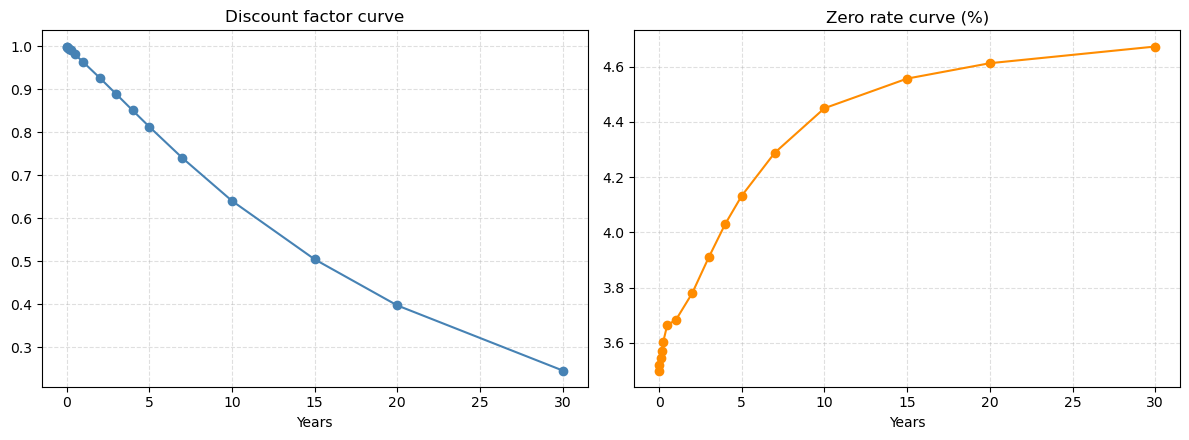

smooth decay and an upward sloping zero curve: nothing pathological in the bootstrap.


In [2]:
years, dfs, zeros = fi.zero_rates(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(years, dfs, color="steelblue", marker="o")
ax1.set_title("Discount factor curve")
ax1.set_xlabel("Years")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(years, zeros, color="darkorange", marker="o")
ax2.set_title("Zero rate curve (%)")
ax2.set_xlabel("Years")
ax2.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("smooth decay and an upward sloping zero curve: nothing pathological in the bootstrap.")

---
## 2. The interest rate swap pricer

Three quantities carry the whole swap:

$$\text{annuity} = \sum_i D(t_i), \qquad \text{float leg} = D(t_0) - D(t_n), \qquad \text{par rate} = \frac{\text{float leg}}{\text{annuity}}$$

The floating leg telescopes: each payment is $D(t_{i-1}) - D(t_i)$, so the sum collapses to first minus last. That is why no forward projection is needed.

DV01, the value of one basis point, is $\text{annuity} \times 0.0001 \times \text{notional}$. Because swap value is linear in the fixed rate, this is exact rather than an approximation. That linearity matters later: it is what lets the hedge solve in closed form.


In [3]:
result = fi.price_swap(df, tenor=12, notional=10_000_000, npv=100_000, verbose=True)

Tenor      : 12Y  (starting year 0)
Notional   : $10,000,000
Par rate   : 4.5503%
Fixed rate : 4.4413%
NPV        : $100,000
DV01       : $9,174


---
## 3. A coupon bond pricer with real settlement dates

Textbook bond formulas assume settlement on a coupon date. Real trades do not settle so conveniently, so the pricer carries `w`, the fraction of the current coupon period still to run. Cash flow $k$ then lands at $(k + w)/2$ years rather than $(k+1)/2$.

Two prices come out of this, and the distinction matters:

* **Dirty price**: the present value of the remaining cash flows, which is what the buyer actually pays.
* **Clean price**: dirty minus accrued interest, which is what the market quotes.

Yield to maturity is then solved by root finding as the single flat rate that reproduces the curve based price. Yield is an output here, never an input.


In [4]:
result = fi.bond_pricer(
    coupon_annual_pct=0.10,
    face=100,
    df_curve=df,
    settlement_date=date(2026, 3, 19),
    prev_coupon_date=date(2025, 11, 21),
    first_coupon_date=date(2026, 5, 21),
    maturity_date=date(2030, 5, 21),
    verbose=True,
)

--------------------------------------------------------------------
  Coupon 10.000%  |  9 periods  |  act/act
  Settlement 2026-03-19  |  Maturity 2030-05-21
  w = 0.3481  (63 days to next coupon / 181)
--------------------------------------------------------------------
  Dirty      : 125.8485
  Accrued    : 3.2597
  Clean      : 122.5889
  PV ($)     : $1,258,485
  YTM        : 4.0592%
  Mod dur    : 3.4263 yrs
  Convexity  : 14.8480
  DV01       : $431.20
--------------------------------------------------------------------


---
## 4. The key rate duration engine

A single parallel DV01 hides where on the curve the risk actually sits. **Key rate duration (KRD)** bumps one pillar at a time and reprices, giving a vector instead of a scalar.

The bump is applied as $D \to D \cdot e^{-0.0001 t}$, which raises that pillar's zero rate by exactly one basis point.

KRDs are **additive across positions**, which is the property the whole hedging study rests on. Here it is demonstrated on a small hold to maturity book.


In [5]:
portfolio = [
    {"name": "UST 2Y",     "coupon": 0.0485, "maturity_date": date(2028, 4, 1)},
    {"name": "IG Corp 5Y", "coupon": 0.0520, "maturity_date": date(2031, 4, 1)},
    {"name": "UST 7Y",     "coupon": 0.0460, "maturity_date": date(2033, 4, 1)},
    {"name": "UST 10Y",    "coupon": 0.0450, "maturity_date": date(2036, 4, 1)},
    {"name": "UST 15Y",    "coupon": 0.0475, "maturity_date": date(2041, 4, 1)},
]
for bond in portfolio:
    bond["face"] = 100
    bond["notional"] = 2_000_000
    bond["settlement_date"]   = date(2026, 4, 1)
    bond["prev_coupon_date"]  = date(2025, 10, 1)
    bond["first_coupon_date"] = date(2026, 10, 1)

krd_tenors = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]

def price_bond_on(bond, curve):
    r=fi.bond_pricer(bond["coupon"], bond["face"], curve,
                       bond["settlement_date"], bond["prev_coupon_date"],
                       bond["first_coupon_date"], bond["maturity_date"],
                       notional=bond["notional"])
    return r["pv"]

original_prices = {}
for bond in portfolio:
    original_prices[bond["name"]] = price_bond_on(bond, df)

import pandas as pd
results = []
for tenor in krd_tenors:
    bumped_curve = fi.bump_curve(df, tenor)
    row = {"Tenor": str(tenor) + "Y"}
    portfolio_krd = 0.0
    for bond in portfolio:
        krd = original_prices[bond["name"]] - price_bond_on(bond, bumped_curve)
        row[bond["name"]] = round(krd, 2)
        portfolio_krd += krd
    row["Portfolio Total"] = round(portfolio_krd, 2)
    results.append(row)

krd_df = pd.DataFrame(results).set_index("Tenor")
print("Key rate DV01 by tenor ($)")
print("-" * 78)
print(krd_df.to_string())
print("-" * 78)

bucket_total = krd_df["Portfolio Total"].sum()
standalone = 0.0
for bond in portfolio:
    r=fi.bond_pricer(bond["coupon"], bond["face"], df,
                       bond["settlement_date"], bond["prev_coupon_date"],
                       bond["first_coupon_date"], bond["maturity_date"],
                       notional=bond["notional"])
    standalone += r["dv01"]
print(f"Sum of KRD buckets      : ${bucket_total:,.0f}")
print(f"Sum of standalone DV01s : ${standalone:,.0f}")

Key rate DV01 by tenor ($)
------------------------------------------------------------------------------
       UST 2Y  IG Corp 5Y  UST 7Y  UST 10Y  UST 15Y  Portfolio Total
Tenor                                                               
0.5Y     1.19        1.28    1.13     1.11     1.17             5.88
1Y      55.08        7.52    6.66     6.51     6.87            82.64
2Y     287.39       19.28   17.06    16.69    17.61           358.03
3Y       0.00       27.74   24.54    24.01    25.34           101.64
5Y       0.00      631.56  157.47    54.89    57.93           901.85
7Y       0.00        0.00  955.07   202.76   123.09          1280.92
10Y      0.00        0.00    0.00  1261.13   307.29          1568.42
15Y      0.00        0.00    0.00     0.00  1617.72          1617.72
20Y      0.00        0.00    0.00     0.00     0.00             0.00
30Y      0.00        0.00    0.00     0.00     0.00             0.00
------------------------------------------------------------------

The two totals are close but not equal, and they should not be. A KRD bumps individual zero curve nodes, while a standalone DV01 shifts the bond's own yield by a basis point. Those are different shocks. A small gap validates the engine; an exact match would be suspicious.

---
## 5. The binomial short rate lattice

A callable bond's cash flows are not fixed. Whether years 3, 4 and 5 exist depends on where rates are at year 2, so there is nothing to discount until the future is modelled. That is what the lattice provides.

**Node geometry.** Within a step, nodes are spaced $r_j = r_{low} \cdot e^{2j\sigma}$. This is the Black-Derman-Toy convention and it makes rates lognormal, so they cannot go negative and spacing widens as rates rise. Each step has exactly one unknown.

**Calibration.** A tree is only usable if it is arbitrage free, meaning it reprices instruments already observed. For each step, root finding solves for the single $r_{low}$ that makes a par bond of that maturity value back to 100 on the tree built so far. Fabozzi describes this as trial and error; `brentq` is the same procedure automated.

Validation below is node by node against Exhibit 37-9, not just on the final price.


In [6]:
# Exhibit 37-4 par curve: 1y 3.50, 2y 4.20, 3y 4.70, 4y 5.20
fabozzi_par = [0.035, 0.042, 0.047, 0.052]

tree = fi.build_tree(fabozzi_par, vol=0.10)
book_nodes = [[3.5000],
              [4.4448, 5.4289],
              [4.6958, 5.7354, 7.0053],
              [5.0483, 6.1660, 7.5312, 9.1987]]

print("Calibrated tree vs Exhibit 37-9 (vol = 10%):")
for t in range(len(tree)):
    mine = ["%.4f%%" % (r * 100) for r in tree[t]]
    book = ["%.4f%%" % b for b in book_nodes[t]]
    print(f"  Year {t}:  mine {mine}")
    print(f"           book {book}")

Calibrated tree vs Exhibit 37-9 (vol = 10%):
  Year 0:  mine ['3.5000%']
           book ['3.5000%']
  Year 1:  mine ['4.4448%', '5.4289%']
           book ['4.4448%', '5.4289%']
  Year 2:  mine ['4.6958%', '5.7354%', '7.0053%']
           book ['4.6958%', '5.7354%', '7.0053%']
  Year 3:  mine ['5.0483%', '6.1660%', '7.5312%', '9.1986%']
           book ['5.0483%', '6.1660%', '7.5312%', '9.1987%']


**Valuation** rolls backward from maturity. Each node is the discounted average of its two successors plus the coupon, with risk neutral probabilities of one half by construction.

The option is a single line inside that loop:

```python
if call:  v = min(call_price, v)     # the issuer's choice
if put:   v = max(put_price, v)      # the investor's choice
```

The issuer retires the bond when keeping it alive costs more than the call price. Flipping `min` to `max` with the investor's strike gives a putable bond, which is why the putable price is checked too: if the recursion is genuinely general, it should reproduce that number without any tuning.


In [7]:
price_free = fi.bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10)
price_call = fi.bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                                    call=True, call_price=100, first_call_year=1)
price_put = fi.bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                                    put=True, put_price=100, first_put_year=1)

print(f"Option-free 6.5% 4Y : {price_free:.3f}   (Exhibit 37-10: 104.643)")
print(f"Callable at par     : {price_call:.3f}   (Exhibit 37-12: 102.899)")
print(f"Putable at par      : {price_put:.3f}   (Exhibit 37-14: 105.327)")
print(f"Call option value   : {price_free - price_call:.3f}    (book: 1.744)")
print(f"Put option value    : {price_put - price_free:.3f}    (book: 0.684)")

Option-free 6.5% 4Y : 104.643   (Exhibit 37-10: 104.643)
Callable at par     : 102.899   (Exhibit 37-12: 102.899)
Putable at par      : 105.327   (Exhibit 37-14: 105.327)
Call option value   : 1.745    (book: 1.744)
Put option value    : 0.684    (book: 0.684)


---
## 6. Option adjusted spread

The model gives a price; the market gives a different one. The **option adjusted spread (OAS)** is the constant spread added to *every node* that reconciles the two. Because the whole tree shifts, an OAS is a spread over the entire curve, not over a single maturity point.

Chapter 37 works the example below: the same callable observed at 102.218, for which the book solves 35 basis points.


In [8]:
market_price = 102.218
oas_solved = fi.solve_oas(market_price, 0.065, 4, fabozzi_par, 0.10,
                          call=True, call_price=100, first_call_year=1)

print(f"model price (OAS = 0)   : {price_call:.3f}")
print(f"market price            : {market_price:.3f}")
print(f"solved OAS              : {oas_solved * 10000:.1f} bp   (book: 35 bp)")

check=fi.bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10, call=True,
                               call_price=100, first_call_year=1, oas=oas_solved)
print(f"reprice at solved OAS   : {check:.3f}")

model price (OAS = 0)   : 102.899
market price            : 102.218
solved OAS              : 35.0 bp   (book: 35 bp)
reprice at solved OAS   : 102.218


One detail in that example carries the entire hedging study that follows. Once the tree is shifted by 35 basis points, the present value at one node falls *below* the call price, so a node that was called in the base tree is no longer called.

**The credit spread changed the exercise decision, not merely the discounting.** Everything in Notebook 2 is a consequence of that.

---
## 7. Effective duration and convexity

Modified duration assumes cash flows do not move when rates move, which is exactly false for a callable. The honest measure reprices the bond on shifted curves:

$$D_{eff} = \frac{V_- - V_+}{2 V_0 \Delta r}, \qquad C_{eff} = \frac{V_+ + V_- - 2V_0}{2 V_0 (\Delta r)^2}$$

The procedural rule that matters: **hold the OAS constant across both bumps**. The question is what this bond does when rates move, not what happens if its credit reprices at the same time.


In [9]:
dr = 0.0025                                  # the chapter's 25bp shift
v0 = market_price

curve_up = [r + dr for r in fabozzi_par]
curve_down = [r - dr for r in fabozzi_par]

v_plus=fi.bond_pricer_lattice(0.065, 4, curve_up,   vol=0.10, call=True,
                                 first_call_year=1, oas=oas_solved)
v_minus = fi.bond_pricer_lattice(0.065, 4, curve_down, vol=0.10, call=True,
                                 first_call_year=1, oas=oas_solved)

eff_dur = (v_minus - v_plus) / (2 * v0 * dr)
eff_cvx = (v_plus + v_minus - 2 * v0) / (2 * v0 * dr ** 2)

print(f"V+  (curve +25bp, same OAS) : {v_plus:.3f}    (book: 101.621)")
print(f"V-  (curve -25bp, same OAS) : {v_minus:.3f}    (book: 102.765)")
print(f"effective duration          : {eff_dur:.2f}       (book: 2.24)")
print(f"effective convexity         : {eff_cvx:.2f}     (book: -39.13)")

V+  (curve +25bp, same OAS) : 101.621    (book: 101.621)
V-  (curve -25bp, same OAS) : 102.765    (book: 102.765)
effective duration          : 2.24       (book: 2.24)
effective convexity         : -38.57     (book: -39.13)


Duration matches exactly. Convexity differs by about half a point because the book computes a second difference from prices rounded to three decimals, and second differences amplify rounding. A first difference like duration is immune to it.

Negative convexity is the signature of the short call: the bond gains less in a rally than it loses in a selloff.